# Heat-pump performance (COP) calibration

Heat-pump efficiency is the one heating-path parameter SERL cannot identify, because the
panel contains too few heat pumps to fit a coefficient of performance. It is anchored
instead to external field data from heatpumpmonitor.org, OpenEnergyMonitor's public
monitoring of real UK installations, through
[`fit_heatpump_cop.py`](../scripts/fit_heatpump_cop.py), which writes
[`heatpump_cop.yaml`](../../../results/field_fits/heatpump_cop.yaml).

The COP is what the policy scenarios convert gas heat through: a converted home's space
heat moves from the gas meter to the electricity meter at `boiler_efficiency / COP`, about
a third of the energy. The calibration supplies two defensible anchors, a conservative
headline and a well-installed sensitivity, and the policy notebook reads both from this
same file rather than assuming a value.

The committed fit is read by default; `RUN_FIT` recomputes it by calling the same
`fit_heatpump_cop.py` the command line runs, which fetches the live field data over the
network.

In [1]:
import os, sys
from pathlib import Path
import numpy as np, yaml
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / "household_energy").exists() and REPO != REPO.parent:
    REPO = REPO.parent
os.chdir(REPO)
sys.path.insert(0, str(REPO / "research" / "policy" / "scripts"))
COP_YAML = REPO / "results" / "field_fits" / "heatpump_cop.yaml"

RUN_FIT = False   # refetch heatpumpmonitor.org field data and refit (network) vs read the committed fit
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

if RUN_FIT:
    from fit_heatpump_cop import main as fit_cop
    fit_cop()   # same code path as the CLI; writes heatpump_cop.yaml

cop = yaml.safe_load(COP_YAML.read_text())
print("anchors (space-heating COP):")
print(f"  conservative (DESNZ Electrification of Heat median): {cop['cop_representative']}")
print(f"  well-installed (field median, space):                {cop['cop_field_median_space']}  (n={cop['diagnostics']['space_cop']['n']})")
print(f"  combined heat + hot water (field median):            {cop['cop_field_median_combined']}")
print("\nmaps to the model as hp_effect_mult = boiler_efficiency / COP:")
for label, c in [("conservative 2.8", cop['cop_representative']), ("well-installed 4.21", cop['cop_field_median_space'])]:
    print(f"  {label:18s}: 0.90 / {c} = {0.90/c:.3f}  (a converted home draws {0.90/c:.0%} of its gas heat as electricity)")

anchors (space-heating COP):
  conservative (DESNZ Electrification of Heat median): 2.8
  well-installed (field median, space):                4.21  (n=464)
  combined heat + hot water (field median):            3.9

maps to the model as hp_effect_mult = boiler_efficiency / COP:
  conservative 2.8  : 0.90 / 2.8 = 0.321  (a converted home draws 32% of its gas heat as electricity)
  well-installed 4.21: 0.90 / 4.21 = 0.214  (a converted home draws 21% of its gas heat as electricity)


## Field distribution and the temperature curve

The left panel is the spread of measured space-heating COP across the monitored fleet; the
right is the Carnot fit of COP against outdoor temperature, which falls as it gets colder,
the physical reason a heat pump works hardest in the weather that needs it most.

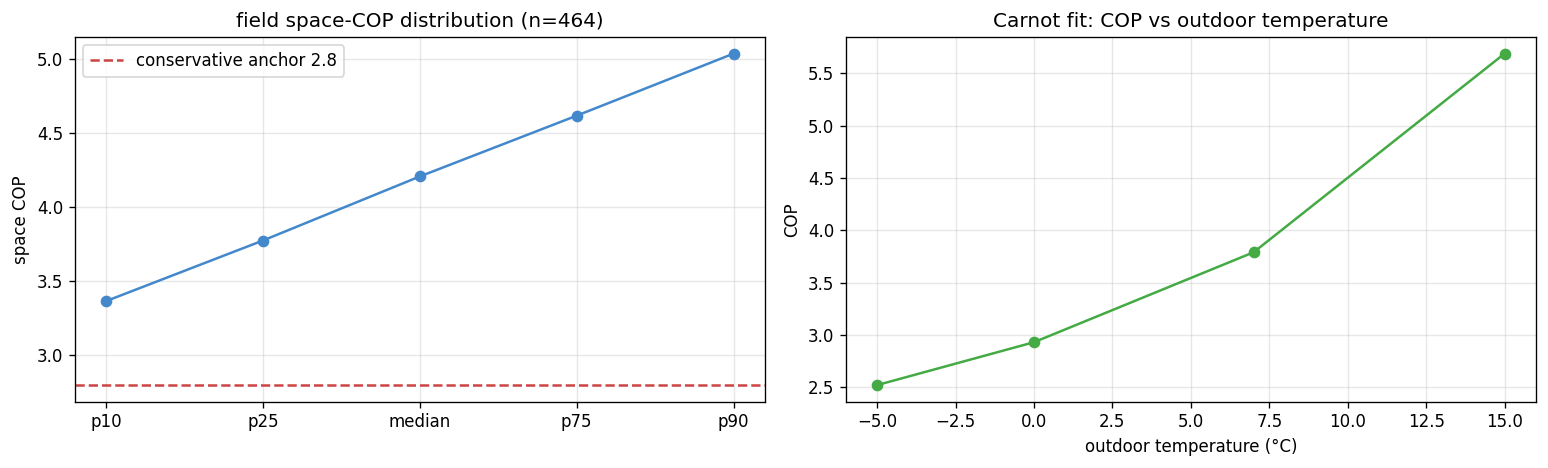

by HP type (space COP): {'Air Source': 4.2, 'Ground Source': 4.58}


In [2]:
d = cop["diagnostics"]["space_cop"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

pcts = ["p10", "p25", "median", "p75", "p90"]; vals = [d[p] for p in pcts]
ax[0].plot(pcts, vals, "-o", color="#48c")
ax[0].axhline(cop["cop_representative"], color="#c44", ls="--",
              label=f"conservative anchor {cop['cop_representative']}")
ax[0].set(ylabel="space COP", title=f"field space-COP distribution (n={d['n']})"); ax[0].legend()

cc = np.array(cop["cop_curve"])
ax[1].plot(cc[:, 0], cc[:, 1], "-o", color="#4a4")
ax[1].set(xlabel="outdoor temperature (°C)", ylabel="COP", title="Carnot fit: COP vs outdoor temperature")
plt.tight_layout()
plt.show()
print("by HP type (space COP):", {k: round(v["median"], 2) for k, v in cop["diagnostics"].get("by_hp_type_space_cop", {}).items()})

## Why the conservative anchor is the headline

The field sample is self-selected: well-commissioned systems owned by enthusiasts who
choose to monitor them, so it is biased above the installed base a policy programme would
actually produce. The model therefore takes the conservative DESNZ Electrification of Heat
median, COP 2.8, as the headline, and uses the field median, 4.21, only as a well-installed
sensitivity. Anchoring high would overstate heat-pump savings, so the conservative default
is the cautious choice for the policy claims that depend on it.

| anchor | COP | source | use |
|---|---|---|---|
| conservative | 2.8 | DESNZ Electrification of Heat trial median (ASHP, SPFH4) | headline |
| well-installed | 4.21 | heatpumpmonitor.org field median (space) | sensitivity |

This file is read by [`heatpump_policy_scenarios.ipynb`](heatpump_policy_scenarios.ipynb),
which converts each treated home's gas heat at `0.90 / COP` and reports the policy result
at the conservative anchor with the well-installed value as a sensitivity.